In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import arch.unitroot as au
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan

import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from statsmodels.tsa.x13 import x13_arima_analysis
import os
import pickle

In [13]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')

FileNotFoundError: [Errno 2] No such file or directory: 'База данных_рег и фед показатели.xlsx'

In [ ]:
# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [ ]:
df_reg.head()

In [ ]:
df_RF.head()

In [ ]:
###############################
# Подсчет ожидаемого уровня инфляции за 12 месяцев
###############################

def calculate_expected_inflation_12m(df, date_col='Date', 
                                     inflation_col='Inflation_Expectations'):
    """
    Расчет ожидаемой инфляции на 12 месяцев вперед
    
    Если данные на следующий год отсутствуют (последние 12 месяцев),
    используются значения текущего года в качестве прокси
    """
    df_calc = df.copy()

    df_calc['Month'] = df_calc[date_col].dt.month
    df_calc['Year'] = df_calc[date_col].dt.year

    # i_1 = количество месяцев до конца текущего года
    df_calc['i_1'] = 12 - df_calc['Month'] + 1
    
    # i_2 = количество месяцев до конца следующего года
    df_calc['i_2'] = 12 + df_calc['i_1']
    
    print(df_calc[['Date', 'Month', 'i_1', 'i_2']].head(10).to_string())

    # Ожидаемая инфляция на конец текущего года
    df_calc['pi_current_year'] = df_calc[inflation_col]
    
    # Ожидаемая инфляция на конец следующего года
    df_calc['pi_next_year'] = df_calc[inflation_col].shift(-12)
    
    # Если нет данных на следующий год, используем значение текущего года в качестве прокси
    df_calc['pi_next_year'] = df_calc['pi_next_year'].fillna(df_calc['pi_current_year'])
    
    print(df_calc[[date_col, 'pi_current_year', 'pi_next_year']].head(15).to_string())

    # Расчет ожидаемой инфляции на 12 месяцев
    df_calc['Expected_Inflation_12m'] = (
        df_calc['pi_current_year'] + 
        (12 - df_calc['i_1']) * (df_calc['pi_next_year'] - df_calc['pi_current_year']) / 12
    )
    
    return df_calc

In [ ]:
df_RF = calculate_expected_inflation_12m(
                df_RF,
                date_col='Date',
                inflation_col='Inflation_Expectations')
df_RF = df_RF.drop(['i_1', 'i_2'], axis=1)

In [ ]:
df_RF.tail()

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ
###############################
descriptive_df = df_RF[[
    'ROISFIX',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
    #VIF-анализ - начальные данные
###############################

vif_variables = [
    'ROISFIX',
    'Expected_Inflation_12m',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_mining',
    'Ent_conf_ind_manufactoring'
]
df_vif = df_RF[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - НАЧАЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
##############################
# Тест Фридмана на сезонность
##############################

variables_for_analysis = [
    ('ROISFIX', 'Ключевая ставка (ROISFIX)'),
    ('Expected_Inflation_12m', 'Ожидаемая инфляция на 12м'),
    ('Nominal_Percent_Rate', 'Номинальная ставка'),
    ('Ent_conf_ind_mining', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring', 'Индекс уверенности (обработка)')
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [3]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))

    


NameError: name 'variables_for_analysis' is not defined

[Ent_conf_ind_mining] Период: 2019-02, наблюдений: 81
[Ent_conf_ind_mining] Сезонная корректировка выполнена
[Ent_conf_ind_mining] Снижение волатильности: 8.6%
[Ent_conf_ind_manufactoring] Период: 2019-02, наблюдений: 81
[Ent_conf_ind_manufactoring] Сезонная корректировка выполнена
[Ent_conf_ind_manufactoring] Снижение волатильности: 5.8%

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF
Ent_conf_ind_mining_adj: 81 не-NaN значений
Ent_conf_ind_mining_trend: 81 не-NaN значений
Ent_conf_ind_mining_seasonal: 81 не-NaN значений
Ent_conf_ind_manufactoring_adj: 81 не-NaN значений
Ent_conf_ind_manufactoring_trend: 81 не-NaN значений
Ent_conf_ind_manufactoring_seasonal: 81 не-NaN значений

Всего добавлено столбцов: 6

СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКЦИИ
                    Переменная Снижение волатильности До корректировки После корректировки
   Индекс уверенности (добыча)                   8.6%           2.1564              1.9712
Индекс уверенности (обработка)                   5.8%           3.3991 

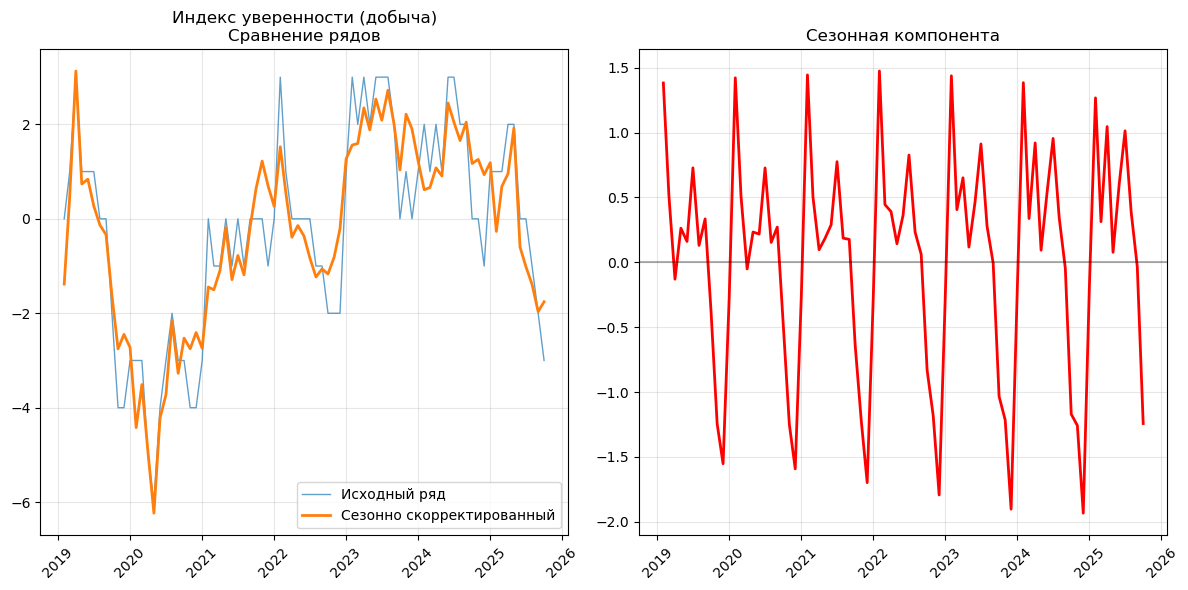

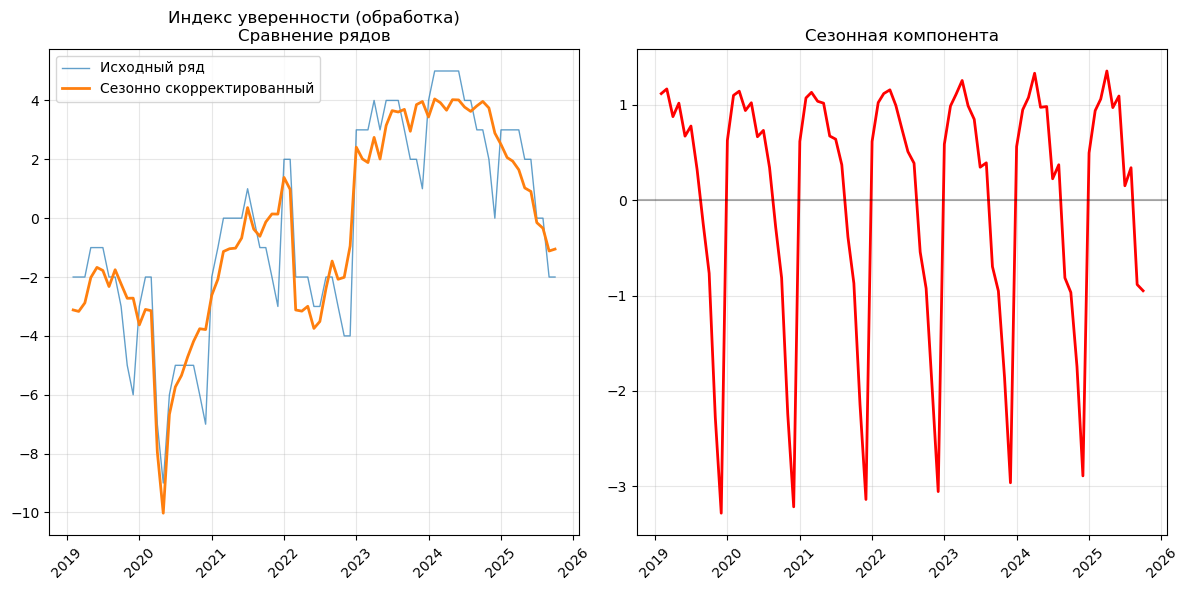

Все скорректированные ряды добавлены в df_RF
Столбцы с суффиксами: _adj, _trend, _seasonal


In [14]:
import json
from pathlib import Path

# Point to your settings file
json_path = Path("x13.json")  
# Load settings
with json_path.open(encoding="utf-8") as f:
    x13_settings = json.load(f)


# Путь к бинарнику X-13
X13_PATH = x13_settings['x13_path']   # либо каталог с бинарником, либо сам бинарник [web:2][web:8]

# Проверка, что бинарник доступен
if not os.path.exists(X13_PATH):
    raise FileNotFoundError(f"X-13 binary not found at {X13_PATH}")

# Если X13_PATH — полный путь к бинарнику, берем его директорию для x12path
x13_dir = X13_PATH if os.path.isdir(X13_PATH) else os.path.dirname(X13_PATH)

# Переменные для сезонной корректировки
x13_variables = {
     #'Expected_Inflation_12m': 'Ожидаемая инфляция (12м)',
    'Ent_conf_ind_mining': 'Индекс уверенности (добыча)',
    'Ent_conf_ind_manufactoring': 'Индекс уверенности (обработка)'
}

os.makedirs("x13_logs", exist_ok=True)

for col, name in x13_variables.items():
    try:
        # Подготовка данных
        series_data = df_RF[['Date', col]].copy().dropna()

        if len(series_data) < 24:
            print(f"[{col}] Недостаточно данных ({len(series_data)} наблюдений). Пропуск.")
            continue

        # Устанавливаем Date как индекс и приводим к месячной частоте (start of month)
        temp_df = series_data.set_index('Date').asfreq('MS').dropna()

        if len(temp_df) < 24:
            print(f"[{col}] Менее 24 наблюдений после asfreq/NA. Пропуск.")
            continue

        print(f"[{col}] Период: {temp_df.index[0].year}-{temp_df.index[0].month:02d}, "
              f"наблюдений: {len(temp_df)}")

        # Вектор значений как pandas.Series с DatetimeIndex
        ts = temp_df[col]

        # Запуск X-13 (аналог seasonal::seas с SEATS)
        # По умолчанию statsmodels использует X-11; для полной эквивалентности
        # с SEATS могут потребоваться кастомные спецификации, но базовая декомпозиция
        # (seasadj, trend, irregular) доступна сразу. [web:2][web:8]
        res = x13_arima_analysis(
            endog=ts,
            x12path=x13_dir,
            prefer_x13=True,
            outlier=True,
            trading=False,
            print_stdout=False
        )

        # Компоненты (названия полей см. в документации statsmodels.X13ArimaAnalysisResult) [web:2][web:8]
        # seasadj: seasonally adjusted
        # trend: trend-cycle
        # irregular: остаток; сезонная компонента = исходный ряд - seasadj
        adj = res.seasadj
        trend = res.trend
        seas = ts - adj

        # Приведение к общему датафрейму
        df_RF.set_index('Date', inplace=True)

        # Создаем столбцы и заполняем только на пересечении индексов
        common_index = df_RF.index.intersection(ts.index)

        df_RF.loc[common_index, f'{col}_adj'] = adj.reindex(common_index)
        df_RF.loc[common_index, f'{col}_trend'] = trend.reindex(common_index)
        df_RF.loc[common_index, f'{col}_seasonal'] = seas.reindex(common_index)

        # Возвращаем индекс Date в столбец (если нужно)
        df_RF.reset_index(inplace=True)

        # Расчет эффективности (снижение волатильности)
        mask = ~df_RF[f'{col}_adj'].isna()
        if mask.any():
            original_std = df_RF.loc[mask, col].std()
            adj_std = df_RF.loc[mask, f'{col}_adj'].std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            print(f"[{col}] Сезонная корректировка выполнена")
            print(f"[{col}] Снижение волатильности: {reduction:.1f}%")

    except Exception as e:
        print(f"[{col}] Ошибка: {e}")


# === ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ ===
print("\n" + "="*60)
print("ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ В DF_RF")
print("="*60)

added_columns = []
for col in x13_variables.keys():
    for suffix in ['_adj', '_trend', '_seasonal']:
        new_col = f'{col}{suffix}'
        if new_col in df_RF.columns:
            added_columns.append(new_col)
            non_na_count = df_RF[new_col].notna().sum()
            print(f"{new_col}: {non_na_count} не-NaN значений")

print(f"\nВсего добавлено столбцов: {len(added_columns)}")

# === СВОДКА РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКЦИИ")
print("="*60)

results_summary = []
for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        mask = ~df_RF[adj_col].isna()
        if mask.any():
            original_data = df_RF.loc[mask, col]
            adj_data = df_RF.loc[mask, adj_col]

            original_std = original_data.std()
            adj_std = adj_data.std()
            reduction = 100 * (1 - adj_std / original_std) if original_std > 0 else 0

            results_summary.append({
                'Переменная': name,
                'Снижение волатильности': f"{reduction:.1f}%",
                'До корректировки': f"{original_std:.4f}",
                'После корректировки': f"{adj_std:.4f}"
            })

if results_summary:
    summary_df = pd.DataFrame(results_summary)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ===
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*60)

for col, name in x13_variables.items():
    adj_col = f'{col}_adj'
    if adj_col in df_RF.columns:
        plot_data = df_RF[['Date', col, adj_col]].dropna(subset=[adj_col])

        if len(plot_data) > 0:
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.plot(plot_data['Date'], plot_data[col],
                     label='Исходный ряд', alpha=0.7, linewidth=1)
            plt.plot(plot_data['Date'], plot_data[adj_col],
                     label='Сезонно скорректированный', linewidth=2)
            plt.title(f'{name}\nСравнение рядов')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.xticks(rotation=45)

            plt.subplot(1, 2, 2)
            seasonal_col = f'{col}_seasonal'
            if seasonal_col in df_RF.columns:
                seasonal_data = df_RF[['Date', seasonal_col]].dropna(subset=[seasonal_col])
                plt.plot(seasonal_data['Date'], seasonal_data[seasonal_col],
                         color='red', linewidth=2)
                plt.title('Сезонная компонента')
                plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
                plt.grid(alpha=0.3)
                plt.xticks(rotation=45)

            plt.tight_layout()
            plt.show()

print("Все скорректированные ряды добавлены в df_RF")
print("Столбцы с суффиксами: _adj, _trend, _seasonal")

In [15]:
df_RF.head()

,Date,Num_reg,Region,CAR_Indicator,D_Progr_mort,ROISFIX,exc_rate,exc_rate_diff,Bonds_Rate_Correct_5Y,Inflation_Expectations,...,Year,pi_current_year,pi_next_year,Expected_Inflation_12m,Ent_conf_ind_mining_adj,Ent_conf_ind_mining_trend,Ent_conf_ind_mining_seasonal,Ent_conf_ind_manufactoring_adj,Ent_conf_ind_manufactoring_trend,Ent_conf_ind_manufactoring_seasonal
0,2019-02-01,0,РОССИЯ,0.146150,0.013333,7.652000,65.810525,-0.702019,0.274500,10.362319,...,2019,10.362319,8.150424,10.177994,-1.382376,0.881282,1.382376,-3.118780,-3.161703,1.118780
1,2019-03-01,0,РОССИЯ,0.146823,0.014805,7.611500,65.092257,-0.718268,0.292500,10.144295,...,2019,10.144295,7.855319,9.762799,0.479521,0.865987,0.520479,-3.167966,-2.871824,1.167966
2,2019-04-01,0,РОССИЯ,0.146778,0.017586,7.630000,64.603105,-0.489152,0.316818,9.004132,...,2019,9.004132,7.845972,8.714592,3.129961,0.828293,-0.129961,-2.877533,-2.571156,0.877533
3,2019-05-01,0,РОССИЯ,0.145500,0.019362,7.635556,64.818706,0.215601,0.295714,9.416996,...,2019,9.416996,8.881323,9.238438,0.737152,0.748407,0.262848,-2.018658,-2.289942,1.018658
4,2019-06-01,0,РОССИЯ,0.144882,0.027592,7.524737,64.169050,-0.649656,0.197895,9.280142,...,2019,9.280142,9.262617,9.272840,0.839312,0.604160,0.160688,-1.672649,-2.049704,0.672649


In [16]:
##############################
# Тест Фридмана для рядов, скорректированных на сезонность
##############################

variables_for_analysis = [
    ('Ent_conf_ind_mining_adj', 'Индекс уверенности (добыча)'),
    ('Ent_conf_ind_manufactoring_adj', 'Индекс уверенности (обработка)')
]

def friedman_seasonality_test(df, date_col='Date', value_col='Variable', 
                              test_name=None):

    df_test = df.copy()
    df_test['Month'] = df_test[date_col].dt.month
    df_test['Year'] = df_test[date_col].dt.year
    
    # Перевод в таблицу: года × месяцы
    pivot_data = df_test.pivot(index='Year', columns='Month', values=value_col)
    
    # Удаляем строки с NaN (неполные годы)
    pivot_data = pivot_data.dropna()
    
    # Проверяем достаточность данных
    if len(pivot_data) < 3:
        print(f"{test_name}: Недостаточно лет ({len(pivot_data)}), минимум 3")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': 'Недостаточно данных'
        }
    
    try:
        # Тест Фридмана
        stat, p_value = friedmanchisquare(*[pivot_data[m].values for m in pivot_data.columns])
        
        # Определяем наличие сезонности
        has_seasonality = p_value < 0.05
        
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': stat,
            'p_value': p_value,
            'has_seasonality': has_seasonality,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': None
        }
    
    except Exception as e:
        print(f"Ошибка для {test_name}: {str(e)}")
        return {
            'variable': test_name if test_name else value_col,
            'chi_squared': np.nan,
            'p_value': np.nan,
            'has_seasonality': np.nan,
            'n_years': len(pivot_data),
            'n_months': len(pivot_data.columns),
            'error': str(e)
        }



In [17]:
# Применяем тест

friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_RF.columns:
        result = friedman_seasonality_test(df_RF, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*60)
print(friedman_summary.to_string(index=False))

    



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                      Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
   Индекс уверенности (добыча)     7.492308 0.757930            False        5        12
Индекс уверенности (обработка)    10.692308 0.469389            False        5        12



РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ

Корреляция итогового индекса с компонентами:
  Итоговый - Добыча: 0.9244
  Итоговый - Обработка: 0.9781


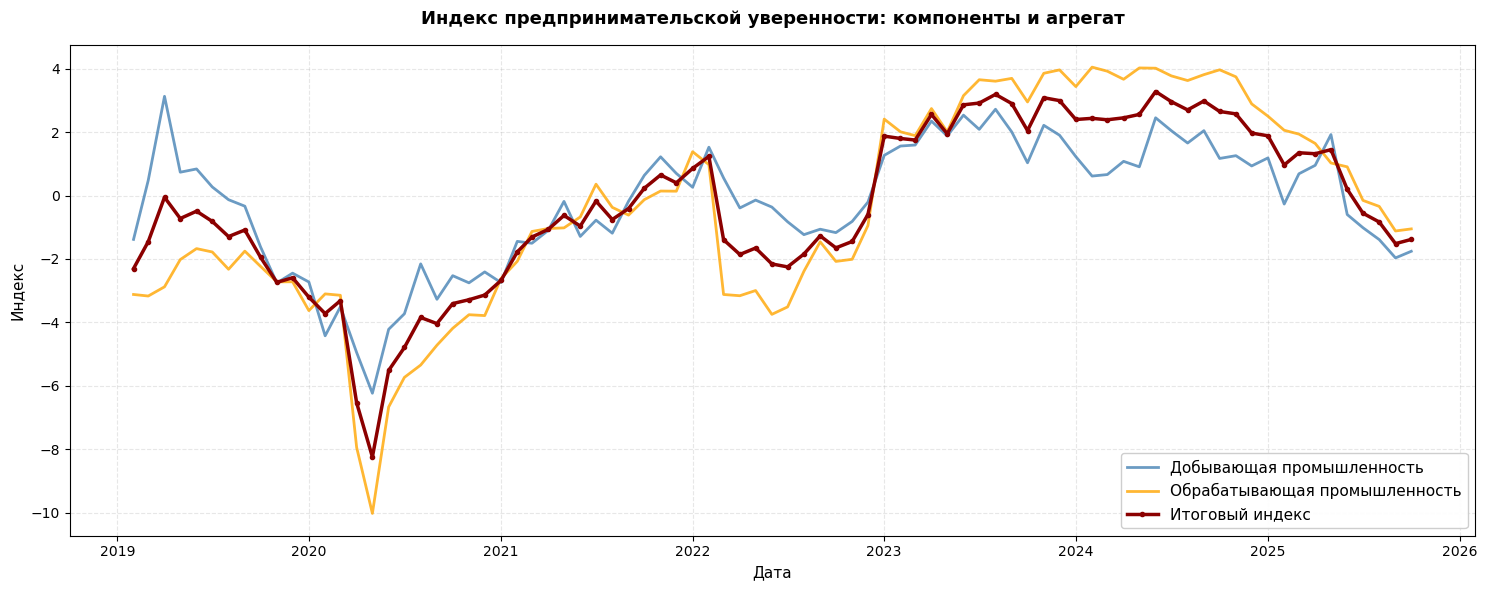

In [18]:
print("\n" + "="*60)
print("РАСЧЕТ ИНДЕКСА ПРЕДПРИНИМАТЕЛЬСКОЙ УВЕРЕННОСТИ")
print("="*60)

# Веса по доле в структуре промышленности РФ (2023 г.)
weights = {
    'mining': 0.47,              # Добывающая промышленность: 47%
    'manufacturing': 0.53        # Обрабатывающая промышленность: 53%
}

mining_col = 'Ent_conf_ind_mining_adj'
manuf_col = 'Ent_conf_ind_manufactoring_adj'

# Проверяем доступность
mining_available = mining_col in df_RF.columns
manuf_available = manuf_col in df_RF.columns


if mining_available and manuf_available:
    # Берем скорректированные данные
    mining_series = df_RF[mining_col].copy()
    manuf_series = df_RF[manuf_col].copy()
    
    # Расчет взвешенного среднего
    df_RF['Ent_conf_ind_total'] = (
        weights['mining'] * mining_series + 
        weights['manufacturing'] * manuf_series
    )    

# Корреляция итогового индекса с компонентами
corr_total_mining = df_RF['Ent_conf_ind_total'].corr(mining_series)
corr_total_manuf = df_RF['Ent_conf_ind_total'].corr(manuf_series)

print(f"\nКорреляция итогового индекса с компонентами:")
print(f"  Итоговый - Добыча: {corr_total_mining:.4f}")
print(f"  Итоговый - Обработка: {corr_total_manuf:.4f}")


fig, ax1 = plt.subplots(figsize=(15, 6))

# График: Компоненты и итоговый индекс
ax1.plot(df_RF['Date'], mining_series, 
         label='Добывающая промышленность', linewidth=2, alpha=0.8, color='steelblue')
ax1.plot(df_RF['Date'], manuf_series, 
         label='Обрабатывающая промышленность', linewidth=2, alpha=0.8, color='orange')
ax1.plot(df_RF['Date'], df_RF['Ent_conf_ind_total'], 
         label='Итоговый индекс', 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)

ax1.set_title('Индекс предпринимательской уверенности: компоненты и агрегат', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('Индекс', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

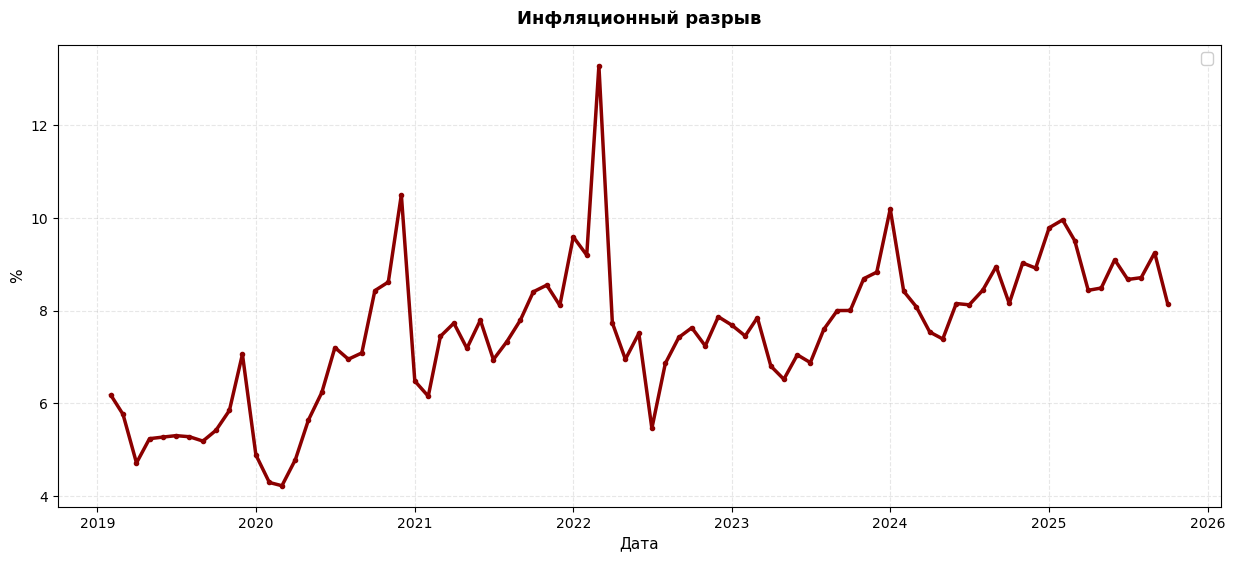

In [19]:
target_inflation = 4.0
df_RF['Inflation_gap'] =  df_RF['Expected_Inflation_12m'] - target_inflation

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_RF['Date'], df_RF['Inflation_gap'], 
         linewidth=2.5, color='darkred', linestyle='-', marker='o', markersize=3)
ax1.set_title('Инфляционный разрыв', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)

In [20]:
df_taylor = df_RF[['Date','ROISFIX', 'Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total', 'Expected_Inflation_12m']]
df_taylor.head()

,Date,ROISFIX,Inflation_gap,Nominal_Percent_Rate,Ent_conf_ind_total,Expected_Inflation_12m
0,2019-02-01,7.652000,6.177994,6.5,-2.302670,10.177994
1,2019-03-01,7.611500,5.762799,6.5,-1.453647,9.762799
2,2019-04-01,7.630000,4.714592,6.5,-0.054011,8.714592
3,2019-05-01,7.635556,5.238438,6.5,-0.723427,9.238438
4,2019-06-01,7.524737,5.272840,6.5,-0.492028,9.272840



РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА

1. Ставка ROISFIX
   Тип данных: Исходный
   Наблюдения: 81
   Тестовые лаги: 19
   Ljung-Box статистика: 534.328
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

2. Инфляционный разрыв
   Тип данных: Исходный
   Наблюдения: 81
   Тестовые лаги: 19
   Ljung-Box статистика: 170.392
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

3. Нейтральная ставка
   Тип данных: Исходный
   Наблюдения: 81
   Тестовые лаги: 19
   Ljung-Box статистика: 407.368
   P-значение: 0.000000
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.000000 ✗
     Лаг  3: p=0.000000 ✗
     Лаг  6: p=0.000000 ✗
     Лаг 12: p=0.000000 ✗

4. Индекс уверенности
   Тип данных: Исходный
   

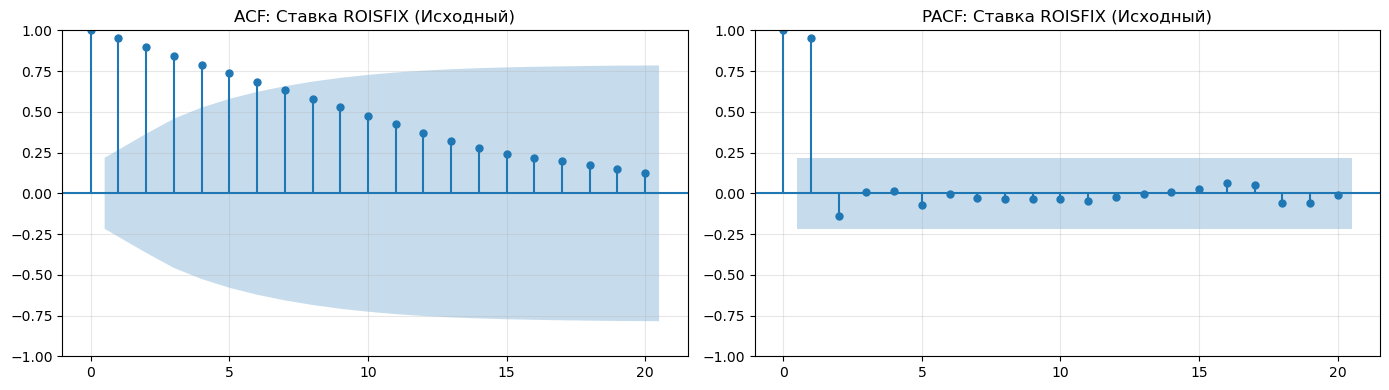

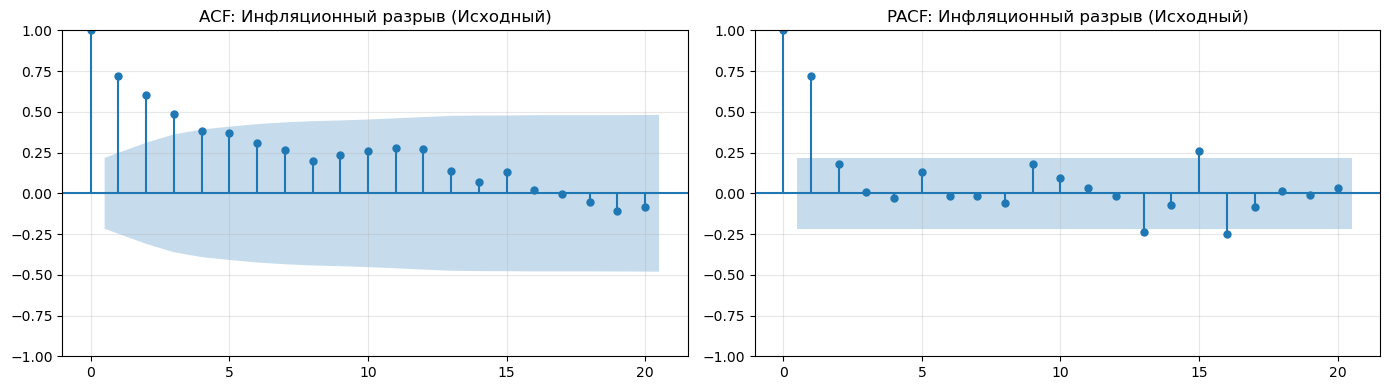

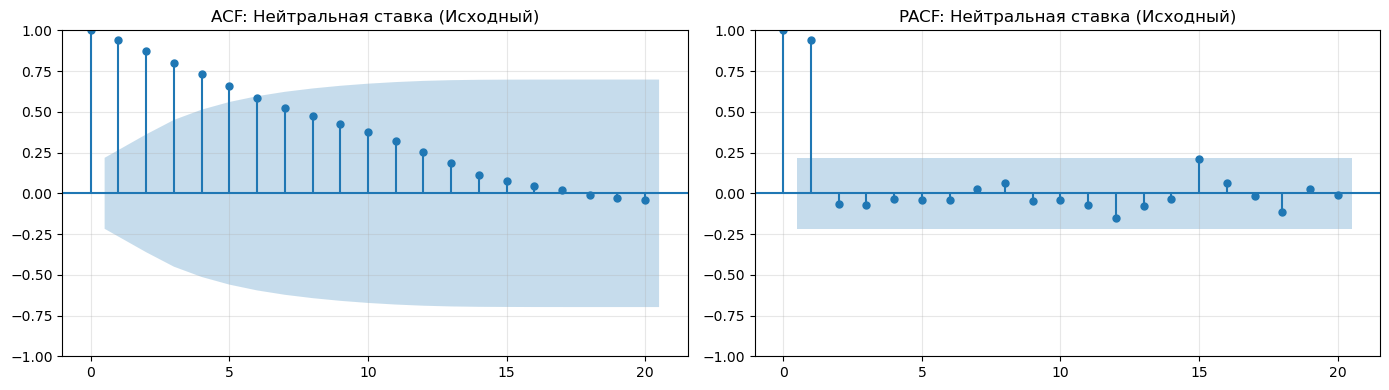

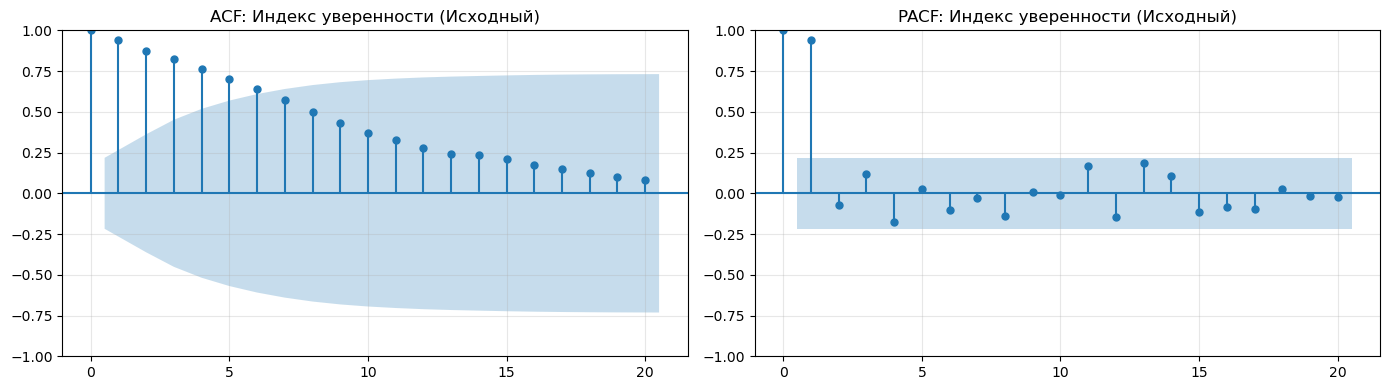

In [21]:
###############################
# Тест Льюинга-Бокса до перехода к разностям
###############################

# === ПЕРЕМЕННЫЕ ДЛЯ ТЕСТА ===
test_variables = {
    'ROISFIX': 'Ставка ROISFIX',
    'Inflation_gap': 'Инфляционный разрыв',
    'Nominal_Percent_Rate': 'Нейтральная ставка',
    'Ent_conf_ind_total': 'Индекс уверенности'
}

# === ФУНКЦИЯ 1: Определяет какой ряд использовать (adj или исходный) ===
def get_series_for_test(df, col_name):
    """
    Проверяет наличие скорректированного ряда (_adj).
    Если есть → возвращает его, иначе возвращает исходный.
    
    Returns:
    --------
    tuple: (series, source_type)
        series : pd.Series - временной ряд
        source_type : str - "Сезонно-скорректированный" или "Исходный"
    """
    
    adj_col = f'{col_name}_adj'
    
    # Проверяем наличие adj столбца и его наполненность
    if adj_col in df.columns:
        adj_series = df[adj_col].dropna()
        if len(adj_series) > 0:
            return adj_series, "Сезонно-скорректированный"
    
    # Если adj не существует или пуст - берем исходный
    original_series = df[col_name].dropna()
    return original_series, "Исходный"

# === ФУНКЦИЯ 2: Тест Льюинга-Бокса ===
def optimized_ljung_box_test(series, name, source_type, max_lags=None):
    """
    Тест Льюинга-Бокса с автоматическим подбором лагов
    
    Parameters:
    -----------
    series : pd.Series или array-like
        Временной ряд для тестирования
    name : str
        Название переменной
    source_type : str
        "Сезонно-скорректированный" или "Исходный"
    max_lags : int, optional
        Максимальное количество лагов
    
    Returns:
    --------
    dict : результаты теста
    """
    
    if len(series) < 30:
        lags = min(10, len(series) - 1)
    else:
        # Автоматический подбор лагов: sqrt(n) + 10 для месячных данных
        lags = min(int(np.sqrt(len(series))) + 10, len(series) - 1)
    
    if max_lags:
        lags = min(lags, max_lags)
    
    # Минимальное количество лагов для теста
    lags = max(5, lags)
    
    try:
        # Основной тест на выбранных лагах
        result = acorr_ljungbox(series, lags=[lags], return_df=True)
        lb_stat = result['lb_stat'].iloc[0]
        lb_pvalue = result['lb_pvalue'].iloc[0]
        
        # Дополнительно проверяем несколько ключевых лагов
        key_lags = [1, 3, 6, 12]
        key_results = []
        
        for lag in key_lags:
            if lag <= lags:
                res = acorr_ljungbox(series, lags=[lag], return_df=True)
                key_results.append({
                    'lag': lag,
                    'pvalue': res['lb_pvalue'].iloc[0]
                })
        
        return {
            'name': name,
            'source_type': source_type,
            'n_obs': len(series),
            'test_lags': lags,
            'lb_statistic': lb_stat,
            'p_value': lb_pvalue,
            'is_white_noise': lb_pvalue > 0.05,
            'key_lags_results': key_results,
            'series': series  # для визуализации
        }
    
    except Exception as e:
        print(f"Ошибка в тесте для {name} ({source_type}): {e}")
        return None

# === ОСНОВНОЙ АНАЛИЗ ===


ljungbox_results = []
problematic_series = []

for col, name in test_variables.items():
    if col not in df_taylor.columns:
        print(f"✗ {name}: столбец '{col}' не найден в df_taylor")
        continue
    
    # Определяем какой ряд использовать
    series, source_type = get_series_for_test(df_taylor, col)
    
    if len(series) < 10:
        print(f"✗ {name}: недостаточно данных (n={len(series)})")
        continue
    
    # Выполняем тест
    result = optimized_ljung_box_test(series, name, source_type)
    
    if result:
        ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ ACF/PACF ДЛЯ ПРОБЛЕМНЫХ РЯДОВ ===

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ ACF/PACF")
print("="*70)

# Визуализируем только для проблемных рядов
if problematic_series:
    for result in problematic_series:
        col_name = None
        for col, name in test_variables.items():
            if name == result['name']:
                col_name = col
                break
        
        if col_name:
            series = result['series']
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # ACF
            plot_acf(series, lags=min(20, len(series)-1), ax=axes[0], alpha=0.05)
            axes[0].set_title(f'ACF: {result["name"]} ({result["source_type"]})')
            axes[0].grid(alpha=0.3)
            
            # PACF
            plot_pacf(series, lags=min(20, len(series)-1), ax=axes[1], alpha=0.05)
            axes[1].set_title(f'PACF: {result["name"]} ({result["source_type"]})')
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
else:
    print("\n✓ Нет проблемных рядов - все переменные имеют приемлемый уровень автокорреляции!")

In [22]:
###############################
    #Тесты на стационарность до перехода к разностям
###############################
variables_to_test = [
    'ROISFIX',
    'Inflation_gap',
    'Nominal_Percent_Rate',
    'Ent_conf_ind_total',
    'Expected_Inflation_12m'
]

df_test = df_taylor[variables_to_test]

def stationarity_tests(series, name):
    series_clean = series.dropna()
    #ADF
    try:
        adf_result = adfuller(series_clean, autolag = 'BIC')
        adf_stat = adf_result[0]
        adf_pvalue = adf_result[1]
        adf_critical_one = adf_result[4]['1%']
        adf_critical_five = adf_result[4]['5%']
        adf_critical_ten = adf_result[4]['10%']
        adf_stationary = adf_pvalue < 0.05
    except Exception as e:
        adf_stat, adf_pvalue, adf_critical_one, adf_critical_five, adf_critical_ten, adf_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )

    #KPSS
    try:
        kpss_result = kpss(series_clean, regression='c', nlags='auto')
        kpss_stat = kpss_result[0]
        kpss_pvalue = kpss_result[1]
        kpss_critical_one = kpss_result[3]['1%']
        kpss_critical_five = kpss_result[3]['5%']
        kpss_critical_ten = kpss_result[3]['10%']
        kpss_stationary = kpss_pvalue > 0.05  # H0: stationary
    except:
        kpss_stat, kpss_pvalue, kpss_critical_one, kpss_critical_five, kpss_critical_ten, kpss_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )
  #DF-GLS
    try:
        DF_GLS_result = au.DFGLS(series_clean, trend='c', max_lags = 2, method = 'bic')
        DF_GLS_stat = DF_GLS_result.stat
        DF_GLS_pvalue = DF_GLS_result.pvalue
        DF_GLS_critical_one =  DF_GLS_result.critical_values['1%']
        DF_GLS_critical_five = DF_GLS_result.critical_values['5%']
        DF_GLS_critical_ten = DF_GLS_result.critical_values['10%']
        DF_GLS_stationary = DF_GLS_pvalue < 0.05  
    except:
        DF_GLS_stat, DF_GLS_pvalue, DF_GLS_critical_one, DF_GLS_critical_five, DF_GLS_critical_ten, DF_GLS_stationary = (
            np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
        )  
    return {
        'Variable': name,
        #ADF
        'ADF_Statistic': adf_stat,
        'ADF_p_value': adf_pvalue,
        'ADF_Critical_1%': adf_critical_one,
        'ADF_Critical_5%': adf_critical_five,
        'ADF_Critical_10%': adf_critical_ten,
        'ADF_Stationary': adf_stationary,
        #KPSS
        'KPSS_Statistic': kpss_stat,
        'KPSS_p_value': kpss_pvalue,
        'KPSS_Critical_1%': kpss_critical_one,
        'KPSS_Critical_5%': kpss_critical_five,
        'KPSS_Critical_10%': kpss_critical_ten,
        'KPSS_Stationary': kpss_stationary,
        # DF-GLS
        'DF_GLS_Statistic': DF_GLS_stat,
        'DF_GLS_p_value': DF_GLS_pvalue,
        'DF_GLS_Critical_1%': DF_GLS_critical_one,
        'DF_GLS_Critical_5%': DF_GLS_critical_five,
        'DF_GLS_Critical_10%': DF_GLS_critical_ten,
        'DF_GLS_Stationary': DF_GLS_stationary
    }
stationarity_results = []
for var in df_test.columns:
    result = stationarity_tests(df_test[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ НА СТАЦИОНАРНОСТЬ ДЛЯ НАЧАЛЬНЫХ ДАННЫХ")
print("="*60)
print(stationarity_df.to_string())


РЕЗУЛЬТАТЫ ТЕСТОВ НА СТАЦИОНАРНОСТЬ ДЛЯ НАЧАЛЬНЫХ ДАННЫХ
                 Variable  ADF_Statistic  ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0                 ROISFIX      -1.068025     0.727653        -3.514869        -2.898409         -2.586439           False        1.081903      0.010000             0.739             0.463              0.347            False         -0.896841        0.336382            -2.79971           -2.178904            -1.868043              False
1           Inflation_gap      -3.594486     0.005867        -3.514869        -2.898409         -2.586439            True        0.873649      0.010000             0.739             0.463              0.347            False         -3.134413        0.001820         

In [23]:
###############################
    #Логарифмирование + приведение к первым разностям
###############################
log_vars = {
    'ROISFIX': 'log_ROISFIX',
    'Nominal_Percent_Rate': 'log_Nominal_Percent_Rate'
}

df_log = df_taylor[['Date'] + list(log_vars.keys())].copy()

for var, log_name in log_vars.items():
    if (df_taylor[var] > 0).all():
        df_log[log_name] = np.log(df_taylor[var])
            
# Не логарифмируем т.к. в % и есть значения <0
no_log_vars = ['Inflation_gap', 'Ent_conf_ind_total', 'Expected_Inflation_12m']
df_log['Inflation_gap'] = df_taylor['Inflation_gap']
df_log['Expected_Inflation_12m'] = df_taylor['Expected_Inflation_12m']
df_log['Ent_conf_ind_total'] = df_taylor['Ent_conf_ind_total']

df_diff = df_log.copy()

# Первая разность логарифмов
for log_name in df_log.columns[1:]:
    if log_name.startswith('log_'):
        diff_name = f"D_{log_name}"
        df_diff[diff_name] = df_log[log_name].diff()

# Первая разность не log
for var in no_log_vars:
    if var in df_log.columns:
        diff_name = f"D_{var}"
        df_diff[diff_name] = df_log[var].diff()

columns_to_keep = ['Date'] + [f"D_{name}" for name in df_log.columns[1:] if name.startswith('log_')] + [f"D_{var}" for var in no_log_vars]
df_diff = df_diff[columns_to_keep]

df_diff = df_diff.dropna()
df_diff.head()

,Date,D_log_ROISFIX,D_log_Nominal_Percent_Rate,D_Inflation_gap,D_Ent_conf_ind_total,D_Expected_Inflation_12m
1,2019-03-01,-0.005307,0.0,-0.415195,0.849023,-0.415195
2,2019-04-01,0.002428,0.0,-1.048207,1.399637,-1.048207
3,2019-05-01,0.000728,0.0,0.523846,-0.669417,0.523846
4,2019-06-01,-0.014620,0.0,0.034402,0.231400,0.034402
5,2019-07-01,-0.024679,0.0,0.030949,-0.322945,0.030949


In [24]:
###############################
    #Тесты на стационарность для I(1) переменных
###############################
diff_vars = [col for col in df_diff.columns if col.startswith('D_')]
stationarity_results_diff = []


for var in diff_vars:
    result = stationarity_tests(df_diff[var], var)
    stationarity_results_diff.append(result)

stationarity_df_diff = pd.DataFrame(stationarity_results_diff)
print(stationarity_df_diff.to_string())

                     Variable  ADF_Statistic   ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0               D_log_ROISFIX      -6.339717  2.773957e-08        -3.515977        -2.898886         -2.586694            True        0.112802           0.1             0.739             0.463              0.347             True         -6.347527    2.443406e-09           -2.802369           -2.181474            -1.870699               True
1  D_log_Nominal_Percent_Rate      -8.362377  2.801063e-13        -3.515977        -2.898886         -2.586694            True        0.160941           0.1             0.739             0.463              0.347             True         -8.403775    1.010118e-13           -2.802369           -2.181474            

In [25]:
df_taylor = df_diff.copy()


РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА

1. Логарифм I(1) ставки ROISFIX
   Тип данных: Исходный
   Наблюдения: 80
   Тестовые лаги: 18
   Ljung-Box статистика: 21.609
   P-значение: 0.249820
   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)
   Ключевые лаги:
     Лаг  1: p=0.004225 ✗
     Лаг  3: p=0.033955 ✗
     Лаг  6: p=0.176830 ✓
     Лаг 12: p=0.589119 ✓

2. I(1) инфляционный разрыв
   Тип данных: Исходный
   Наблюдения: 80
   Тестовые лаги: 18
   Ljung-Box статистика: 38.886
   P-значение: 0.002952
   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)
   Ключевые лаги:
     Лаг  1: p=0.004237 ✗
     Лаг  3: p=0.041771 ✗
     Лаг  6: p=0.082247 ✓
     Лаг 12: p=0.066056 ✓

3. Логарифм I(1) нейтральной ставки
   Тип данных: Исходный
   Наблюдения: 80
   Тестовые лаги: 18
   Ljung-Box статистика: 19.826
   P-значение: 0.342713
   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)
   Ключевые лаги:
     Лаг  1: p=0.661021 ✓
     Лаг  3: p=0.946313 ✓
     Лаг  6: p=0.956794 ✓
     Лаг 12: p=0.887406 ✓

4. I(1) индекс ув

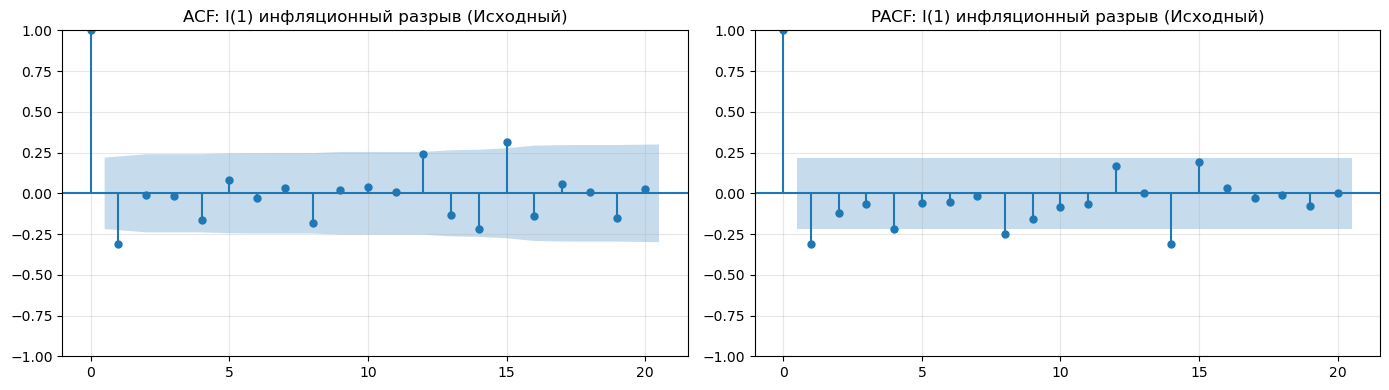

In [26]:
###############################
# Тест Льюинга-Бокса для I(1) переменных
###############################

# === ПЕРЕМЕННЫЕ ДЛЯ ТЕСТА ===
test_variables = {
    'D_log_ROISFIX': 'Логарифм I(1) ставки ROISFIX',
    'D_Inflation_gap': 'I(1) инфляционный разрыв',
    'D_log_Nominal_Percent_Rate': 'Логарифм I(1) нейтральной ставки',
    'D_Ent_conf_ind_total': 'I(1) индекс уверенности'
}

# === ФУНКЦИЯ 1: Определяет какой ряд использовать (adj или исходный) ===
def get_series_for_test(df, col_name):
    """
    Проверяет наличие скорректированного ряда (_adj).
    Если есть → возвращает его, иначе возвращает исходный.
    
    Returns:
    --------
    tuple: (series, source_type)
        series : pd.Series - временной ряд
        source_type : str - "Сезонно-скорректированный" или "Исходный"
    """
    
    adj_col = f'{col_name}_adj'
    
    # Проверяем наличие adj столбца и его наполненность
    if adj_col in df.columns:
        adj_series = df[adj_col].dropna()
        if len(adj_series) > 0:
            return adj_series, "Сезонно-скорректированный"
    
    # Если adj не существует или пуст - берем исходный
    original_series = df[col_name].dropna()
    return original_series, "Исходный"

# === ФУНКЦИЯ 2: Тест Льюинга-Бокса ===
def optimized_ljung_box_test(series, name, source_type, max_lags=None):
    """
    Тест Льюинга-Бокса с автоматическим подбором лагов
    
    Parameters:
    -----------
    series : pd.Series или array-like
        Временной ряд для тестирования
    name : str
        Название переменной
    source_type : str
        "Сезонно-скорректированный" или "Исходный"
    max_lags : int, optional
        Максимальное количество лагов
    
    Returns:
    --------
    dict : результаты теста
    """
    
    if len(series) < 30:
        lags = min(10, len(series) - 1)
    else:
        # Автоматический подбор лагов: sqrt(n) + 10 для месячных данных
        lags = min(int(np.sqrt(len(series))) + 10, len(series) - 1)
    
    if max_lags:
        lags = min(lags, max_lags)
    
    # Минимальное количество лагов для теста
    lags = max(5, lags)
    
    try:
        # Основной тест на выбранных лагах
        result = acorr_ljungbox(series, lags=[lags], return_df=True)
        lb_stat = result['lb_stat'].iloc[0]
        lb_pvalue = result['lb_pvalue'].iloc[0]
        
        # Дополнительно проверяем несколько ключевых лагов
        key_lags = [1, 3, 6, 12]
        key_results = []
        
        for lag in key_lags:
            if lag <= lags:
                res = acorr_ljungbox(series, lags=[lag], return_df=True)
                key_results.append({
                    'lag': lag,
                    'pvalue': res['lb_pvalue'].iloc[0]
                })
        
        return {
            'name': name,
            'source_type': source_type,
            'n_obs': len(series),
            'test_lags': lags,
            'lb_statistic': lb_stat,
            'p_value': lb_pvalue,
            'is_white_noise': lb_pvalue > 0.05,
            'key_lags_results': key_results,
            'series': series  # для визуализации
        }
    
    except Exception as e:
        print(f"Ошибка в тесте для {name} ({source_type}): {e}")
        return None

# === ОСНОВНОЙ АНАЛИЗ ===


ljungbox_results = []
problematic_series = []

for col, name in test_variables.items():
    if col not in df_taylor.columns:
        print(f"✗ {name}: столбец '{col}' не найден в df_taylor")
        continue
    
    # Определяем какой ряд использовать
    series, source_type = get_series_for_test(df_taylor, col)
    
    if len(series) < 10:
        print(f"✗ {name}: недостаточно данных (n={len(series)})")
        continue
    
    # Выполняем тест
    result = optimized_ljung_box_test(series, name, source_type)
    
    if result:
        ljungbox_results.append(result)

# === ВЫВОД РЕЗУЛЬТАТОВ ===

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ТЕСТА ЛЬЮИНГА-БОКСА")
print("="*70)

if ljungbox_results:
    for i, result in enumerate(ljungbox_results, 1):
        print(f"\n{i}. {result['name']}")
        print(f"   Тип данных: {result['source_type']}")
        print(f"   Наблюдения: {result['n_obs']}")
        print(f"   Тестовые лаги: {result['test_lags']}")
        print(f"   Ljung-Box статистика: {result['lb_statistic']:.3f}")
        print(f"   P-значение: {result['p_value']:.6f}")
        
        if result['is_white_noise']:
            print(f"   ✓ ОСТАТКИ БЕЗ АВТОКОРРЕЛЯЦИИ (p > 0.05)")
        else:
            print(f"   ✗ ОБНАРУЖЕНА АВТОКОРРЕЛЯЦИЯ (p < 0.05)")
            problematic_series.append(result)
        
        # Ключевые лаги
        print(f"   Ключевые лаги:")
        for key_res in result['key_lags_results']:
            sig_mark = "✓" if key_res['pvalue'] > 0.05 else "✗"
            print(f"     Лаг {key_res['lag']:2d}: p={key_res['pvalue']:.6f} {sig_mark}")

# === СВОДНАЯ ТАБЛИЦА ===

if ljungbox_results:
    print("\n" + "="*70)
    print("СВОДНАЯ ТАБЛИЦА")
    print("="*70)
    
    summary_data = []
    for result in ljungbox_results:
        # Подсчитываем количество значимых лагов из ключевых
        sig_lags = sum(1 for res in result['key_lags_results'] if res['pvalue'] < 0.05)
        total_lags = len(result['key_lags_results'])
        
        # Определяем статус
        if result['is_white_noise']:
            status = "✓ OK"
        elif sig_lags <= 2:
            status = "⚠ Приемлемо"
        else:
            status = "✗ Проблема"
        
        summary_data.append({
            'Переменная': result['name'],
            'Тип данных': result['source_type'],
            'N': result['n_obs'],
            'P-значение': f"{result['p_value']:.6f}",
            'Значимые лаги': f"{sig_lags}/{total_lags}",
            'Статус': status
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

# === ВИЗУАЛИЗАЦИЯ ACF/PACF ДЛЯ ПРОБЛЕМНЫХ РЯДОВ ===

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ ACF/PACF")
print("="*70)

# Визуализируем только для проблемных рядов
if problematic_series:
    for result in problematic_series:
        col_name = None
        for col, name in test_variables.items():
            if name == result['name']:
                col_name = col
                break
        
        if col_name:
            series = result['series']
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            
            # ACF
            plot_acf(series, lags=min(20, len(series)-1), ax=axes[0], alpha=0.05)
            axes[0].set_title(f'ACF: {result["name"]} ({result["source_type"]})')
            axes[0].grid(alpha=0.3)
            
            # PACF
            plot_pacf(series, lags=min(20, len(series)-1), ax=axes[1], alpha=0.05)
            axes[1].set_title(f'PACF: {result["name"]} ({result["source_type"]})')
            axes[1].grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
else:
    print("\n✓ Нет проблемных рядов - все переменные имеют приемлемый уровень автокорреляции!")

In [27]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ
###############################
descriptive_df = df_taylor[[
    'D_log_ROISFIX',
    'D_Inflation_gap',
    'D_log_Nominal_Percent_Rate',
    'D_Ent_conf_ind_total'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ОБРАБОТАННЫЕ ДАННЫЕ
                            Среднее  Медиана  ст. откл.   Мин.  Макс.
D_log_ROISFIX                 0.010    0.000      0.116 -0.298  0.741
D_Inflation_gap               0.025    0.138      1.176 -5.551  4.088
D_log_Nominal_Percent_Rate    0.003    0.000      0.041 -0.167  0.241
D_Ent_conf_ind_total          0.011    0.058      0.843 -3.219  2.726


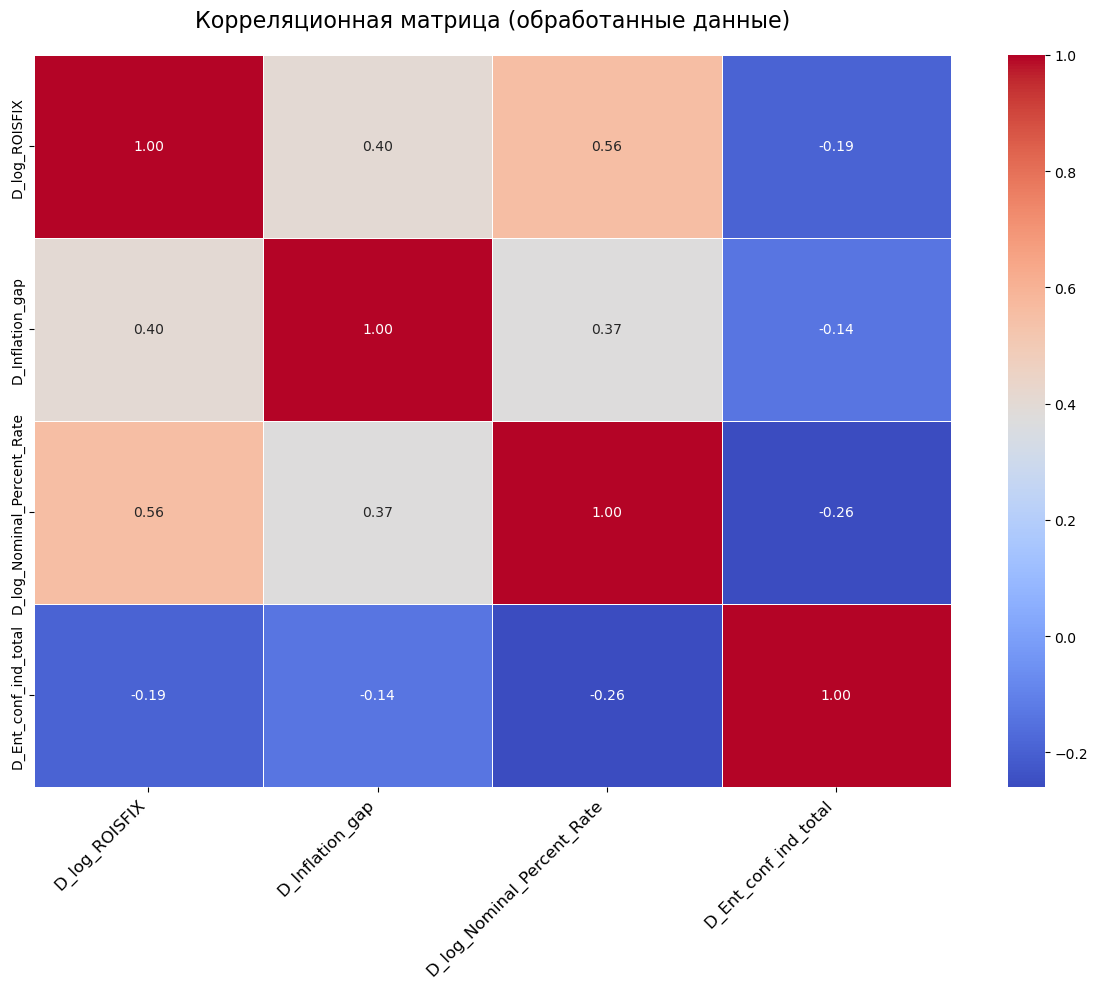

In [28]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ОБРАБОТАННЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (обработанные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [29]:
###############################
    #VIF-анализ - обработанные данные
###############################

vif_variables = [
    'D_log_ROISFIX',
    'D_Inflation_gap',
    'D_log_Nominal_Percent_Rate',
    'D_Ent_conf_ind_total'
]
df_vif = df_taylor[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ОБРАБОТАННЫЕ ДАННЫЕ")
print("="*60)
print(vif_data.to_string(index=False))


РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ОБРАБОТАННЫЕ ДАННЫЕ
                  Variable      VIF
D_log_Nominal_Percent_Rate 1.555392
             D_log_ROISFIX 1.554556
           D_Inflation_gap 1.241706
      D_Ent_conf_ind_total 1.076955


In [30]:
###############################
    #Тест Йохансена на поиск коинтегрирующего соотношения
###############################
print("\n" + "="*60)
print("ТЕСТ ЙОХАНСЕНА")
print("="*60)

# === ДАННЫЕ В УРОВНЯХ ===
df_johansen = df_RF[['ROISFIX', 'Inflation_gap', 'Nominal_Percent_Rate', 'Ent_conf_ind_total']].dropna()

print(f"\nДанные: {len(df_johansen)} наблюдений")
print(f"Период: {df_RF['Date'].min()} - {df_RF['Date'].max()}")

# === ТЕСТ ЙОХАНСЕНА ===
print("\n" + "="*60)
print("Тестирование на коинтеграцию используемых временных рядов")
print("Результаты проведения теста Йохансена на поиск коинтегрирующего соотношения")
print("Статистика Trace Value")
print("="*60)

johansen = coint_johansen(df_johansen, det_order=0, k_ar_diff=1)

# Таблица результатов Trace test
print(f"\n{'r':<6} {'Test':<10} {'10%':<10} {'5%':<10} {'1%':<10} {'Result':<15}")
print("-"*60)

rank = 0
k = len(df_johansen.columns)

for r in range(k):
    stat = johansen.lr1[r]
    crit_10 = johansen.cvt[r, 0]
    crit_5 = johansen.cvt[r, 1]
    crit_1 = johansen.cvt[r, 2]
    
    # ПРАВИЛЬНАЯ логика определения ранга:
    # H0: ранг коинтеграции <= r
    # H1: ранг коинтеграции > r
    
    if stat > crit_5:
        result_text = "✓ Reject H0"
    else:
        result_text = "✗ Accept H0"
        rank = r
        break
else:
    # Если отвергли все гипотезы (для всех r от 0 до k-1), то ранг = k
    rank = k

print(f"{r:<6} {stat:<10.2f} {crit_10:<10.2f} {crit_5:<10.2f} {crit_1:<10.2f} {result_text:<15}")

# ВЫВОДИМ ВСЕ СТРОКИ ТАБЛИЦЫ ДЛЯ ПРОЗРАЧНОСТИ
for r_display in range(k):
    if r_display != r:  
        stat_display = johansen.lr1[r_display]
        crit_10_display = johansen.cvt[r_display, 0]
        crit_5_display = johansen.cvt[r_display, 1]
        crit_1_display = johansen.cvt[r_display, 2]
        
        if stat_display > crit_5_display:
            result_text_display = "✓ Reject H0"
        else:
            result_text_display = "✗ Accept H0"
            
        print(f"{r_display:<6} {stat_display:<10.2f} {crit_10_display:<10.2f} {crit_5_display:<10.2f} {crit_1_display:<10.2f} {result_text_display:<15}")

print(f"\n→ Ранг коинтеграции: r = {rank}")

# === ЛИНЕЙНАЯ КОМБИНАЦИЯ ИССЛЕДУЕМЫХ РЯДОВ ===
print("\n" + "="*60)
print("Линейная комбинация исследуемых рядов")
print("="*60)

if rank > 0:
    # Нормализуем первый собственный вектор (коинтеграционный вектор)
    beta = johansen.evec[:, 0].copy()
    beta = beta / beta[0]

    print(f"\nКоинтеграционный вектор (β):")
    print(f"(долгосрочное равновесное соотношение)\n")

    # Названия переменных как в таблице
    var_display_names = [
        'Key_Rate_t',
        'Inflation_Expectations_12m_t', 
        'Output_Gap_t',
        'Neutral_Rate_t'
    ]

    for i, display_name in enumerate(var_display_names):
        coef = beta[i]
        print(f"{display_name:<35} {coef:>15.7f}")
else:
    print("\nКоинтеграционные векторы не найдены")


ТЕСТ ЙОХАНСЕНА

Данные: 81 наблюдений
Период: 2019-02-01 00:00:00 - 2025-10-01 00:00:00

Тестирование на коинтеграцию используемых временных рядов
Результаты проведения теста Йохансена на поиск коинтегрирующего соотношения
Статистика Trace Value

r      Test       10%        5%         1%         Result         
------------------------------------------------------------
1      23.90      27.07      29.80      35.46      ✗ Accept H0    
0      49.67      44.49      47.85      54.68      ✓ Reject H0    
2      13.91      13.43      15.49      19.93      ✗ Accept H0    
3      5.56       2.71       3.84       6.63       ✓ Reject H0    

→ Ранг коинтеграции: r = 1

Линейная комбинация исследуемых рядов

Коинтеграционный вектор (β):
(долгосрочное равновесное соотношение)

Key_Rate_t                                1.0000000
Inflation_Expectations_12m_t             -1.5582988
Output_Gap_t                             -3.0954933
Neutral_Rate_t                           -1.0512742


In [31]:
###############################
    #Подготовка финального датасета (добавляем дамми, лаги и прозведения)
###############################

df_taylor['Covid_dum'] = df_RF['Covid_dum']
df_taylor['Sank_dum'] = df_RF['Sank_dum']
df_taylor['L1_D_Inflation_gap'] = df_taylor['D_Inflation_gap'].shift(1)
df_taylor['L1_D_Ent_conf_ind_total'] = df_taylor['D_Ent_conf_ind_total'].shift(1)
df_taylor['L1_D_log_Nominal_Percent_Rate'] = df_taylor['D_log_Nominal_Percent_Rate'].shift(1)  
df_taylor['L1_D_log_ROISFIX'] = df_taylor['D_log_ROISFIX'].shift(1)

df_taylor = df_taylor.dropna()
df_taylor.head()

,Date,D_log_ROISFIX,D_log_Nominal_Percent_Rate,D_Inflation_gap,D_Ent_conf_ind_total,D_Expected_Inflation_12m,Covid_dum,Sank_dum,L1_D_Inflation_gap,L1_D_Ent_conf_ind_total,L1_D_log_Nominal_Percent_Rate,L1_D_log_ROISFIX
2,2019-04-01,0.002428,0.0,-1.048207,1.399637,-1.048207,0,0,-0.415195,0.849023,0.0,-0.005307
3,2019-05-01,0.000728,0.0,0.523846,-0.669417,0.523846,0,0,-1.048207,1.399637,0.0,0.002428
4,2019-06-01,-0.014620,0.0,0.034402,0.231400,0.034402,0,0,0.523846,-0.669417,0.0,0.000728
5,2019-07-01,-0.024679,0.0,0.030949,-0.322945,0.030949,0,0,0.034402,0.231400,0.0,-0.014620
6,2019-08-01,-0.029715,0.0,-0.023716,-0.477790,-0.023716,0,0,0.030949,-0.322945,0.0,-0.024679


In [32]:
###############################
# Тест White и Breusch-Pagan на гетероскедастичность
###############################
print("\n" + "="*60)
print("ТЕСТЫ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ: WHITE И BREUSCH-PAGAN")
print("="*60)

# Подготавливаем данные для регрессии
X = sm.add_constant(df_taylor[['D_Inflation_gap', 'D_log_Nominal_Percent_Rate', 'D_Ent_conf_ind_total']])
y = df_taylor['D_log_ROISFIX']

# Строим базовую модель OLS
model_ols = sm.OLS(y, X).fit()

# Получаем остатки
residuals = model_ols.resid

print("\nРегрессионная модель:")
print(f"Зависимая переменная: D_log_ROISFIX")
print(f"Количество наблюдений: {len(y)}")
print(f"R-squared: {model_ols.rsquared:.4f}")

# === ТЕСТ BREUSCH-PAGAN ===
print("\n" + "-"*60)
print("ТЕСТ BREUSCH-PAGAN")
print("-"*60)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

bp_stat, bp_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(residuals, X)

print(f"LM-статистика Breusch-Pagan: {bp_stat:.4f}")
print(f"P-значение (LM): {bp_pvalue:.6f}")
print(f"F-статистика: {bp_f_stat:.4f}")
print(f"P-значение (F): {bp_f_pvalue:.6f}")

if bp_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === ТЕСТ WHITE ===
print("\n" + "-"*80)
print("ТЕСТ WHITE")
print("-"*80)
print("H0: Гомоскедастичность (константная дисперсия)")
print("H1: Гетероскедастичность (переменная дисперсия)\n")

white_stat, white_pvalue, white_df, white_fitted = het_white(residuals, X)

print(f"LM-статистика White: {white_stat:.4f}")
print(f"P-значение: {white_pvalue:.6f}")
print(f"Степени свободы: {white_df}")

if white_pvalue < 0.05:
    print("\n ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)")
else:
    print("\n ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)")

# === СВОДНАЯ ТАБЛИЦА ===
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

summary_heteroscedasticity = pd.DataFrame({
    'Тест': ['Breusch-Pagan (LM)', 'Breusch-Pagan (F)', 'White'],
    'Статистика': [f"{bp_stat:.4f}", f"{bp_f_stat:.4f}", f"{white_stat:.4f}"],
    'P-значение': [f"{bp_pvalue:.6f}", f"{bp_f_pvalue:.6f}", f"{white_pvalue:.6f}"],
    'Вывод': [
        ' Гетероскедастичность' if bp_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if bp_f_pvalue < 0.05 else ' Гомоскедастичность',
        ' Гетероскедастичность' if white_pvalue < 0.05 else ' Гомоскедастичность'
    ]
})

print(summary_heteroscedasticity.to_string(index=False))


ТЕСТЫ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ: WHITE И BREUSCH-PAGAN

Регрессионная модель:
Зависимая переменная: D_log_ROISFIX
Количество наблюдений: 79
R-squared: 0.3566

------------------------------------------------------------
ТЕСТ BREUSCH-PAGAN
------------------------------------------------------------
H0: Гомоскедастичность (константная дисперсия)
H1: Гетероскедастичность (переменная дисперсия)

LM-статистика Breusch-Pagan: 1.8803
P-значение (LM): 0.597618
F-статистика: 0.6095
P-значение (F): 0.610888

 ПРИНИМАЕМ H0: НЕТ ЗНАЧИМОЙ ГЕТЕРОСКЕДАСТИЧНОСТИ (p > 0.05)

--------------------------------------------------------------------------------
ТЕСТ WHITE
--------------------------------------------------------------------------------
H0: Гомоскедастичность (константная дисперсия)
H1: Гетероскедастичность (переменная дисперсия)

LM-статистика White: 48.4462
P-значение: 0.000000
Степени свободы: 12.156261911841135

 ОТКЛОНЯЕМ H0: ОБНАРУЖЕНА ГЕТЕРОСКЕДАСТИЧНОСТЬ (p < 0.05)

СВОДНАЯ ТАБЛИЦА РЕЗУ

In [33]:
###############################
# ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ
###############################

def extract_ardl_coefficients(result, y_name, print_results=True):
    """
    Извлекает ключевые коэффициенты из ARDL модели:
    - α (alpha): реакция на инфляцию
    - μ (mu): реакция на уверенность
    - γ (gamma): коэффициент инерции (лаг зависимой переменной)
    """
    params = result.params
    pvalues = result.pvalues
    
    coeffs = {
        'alpha': None,
        'mu': None,
        'gamma': None,
        'alpha_pval': None,
        'mu_pval': None,
        'gamma_pval': None
    }
    
    # Извлечение альфа (инфляция)
    if 'D_Inflation_gap' in params.index:
        coeffs['alpha'] = params['D_Inflation_gap']
        coeffs['alpha_pval'] = pvalues['D_Inflation_gap']
    
    # Извлечение мю (уверенность)
    if 'D_Ent_conf_ind_total' in params.index:
        coeffs['mu'] = params['D_Ent_conf_ind_total']
        coeffs['mu_pval'] = pvalues['D_Ent_conf_ind_total']
    
    # Извлечение гамма (лаг зависимой переменной)
    # Ищем по паттерну: y_lag.1, L.y, D_log_ROISFIX.L1, etc.
    lag_patterns = [
    f'{y_name}.L1',
    f'L.{y_name}',
    f'{y_name}_lag',
    f'{y_name}_lag.1',
    f'{y_name}_L1',
    f'L1_{y_name}',
    ]
    
    for pattern in lag_patterns:
        if pattern in params.index:
            coeffs['gamma'] = params[pattern]
            coeffs['gamma_pval'] = pvalues[pattern]
            coeffs['gamma_name'] = pattern
            break
    
    # Вывод результатов
    if print_results:
        print("\n" + "="*60)
        print("ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL")
        print("="*60)
        
        # α - реакция на инфляцию
        if coeffs['alpha'] is not None:
            alpha_sr = coeffs['alpha']
            alpha_pval = coeffs['alpha_pval']
            sig_alpha = "***" if alpha_pval < 0.01 else ("**" if alpha_pval < 0.05 else "*" if alpha_pval < 0.1 else "")
            print(f"\nα (АЛЬФА) - краткосрочная реакция на инфляцию:")
            print(f"  Значение: {alpha_sr:.6f} {sig_alpha}")
            print(f"  P-value: {alpha_pval:.6f}")
            print(f"  Интерпретация: На 1% рост инфляции, ставка {'растет' if alpha_sr > 0 else 'падает'} на {abs(alpha_sr):.4f}%")
            if alpha_pval < 0.05:
                print(f"  Статистическая значимость: Значима (p < 0.05)")
            else:
                print(f"  Статистическая значимость: Незначима (p > 0.05)")
        else:
            print("\n α (альфа) не найдена в модели")
        
        # μ - реакция на уверенность
        if coeffs['mu'] is not None:
            mu_sr = coeffs['mu']
            mu_pval = coeffs['mu_pval']
            sig_mu = "***" if mu_pval < 0.01 else ("**" if mu_pval < 0.05 else "*" if mu_pval < 0.1 else "")
            print(f"\nμ (МЮ) - краткосрочная реакция на разрыв выпуска:")
            print(f"  Значение: {mu_sr:.6f} {sig_mu}")
            print(f"  P-value: {mu_pval:.6f}")
            print(f"  Интерпретация: На 1 пункт рост уверенности (прокси разрыва выпуска), ставка {'растет' if mu_sr > 0 else 'падает'} на {abs(mu_sr):.4f}%")
            if mu_pval < 0.05:
                print(f"  Статистическая значимость: Значима (p < 0.05)")
            else:
                print(f"  Статистическая значимость: Незначима (p > 0.05)")
        else:
            print("\n μ (мю) не найдена в модели")
        
        # γ - инерция (лагированная ставка)
        if coeffs['gamma'] is not None:
            gamma = coeffs['gamma']
            gamma_pval = coeffs['gamma_pval']
            speed_adj = 1 - gamma
            sig_gamma = "***" if gamma_pval < 0.01 else ("**" if gamma_pval < 0.05 else "*" if gamma_pval < 0.1 else "")
            
            print(f"\nγ (ГАММА) - коэффициент инерции (лаг зависимой переменной):")
            print(f"  Переменная: {coeffs.get('gamma_name', 'неизвестно')}")
            print(f"  Значение: {gamma:.6f} {sig_gamma}")
            print(f"  P-value: {gamma_pval:.6f}")
            
            print(f"\n  Интерпретация:")
            print(f"    - Инерция системы: {gamma:.4f} (доля предыдущего периода)")
            print(f"    - Скорость адаптации к равновесию: {speed_adj:.4f}")
            print(f"    - На каждый период корректируется: {speed_adj*100:.2f}% отклонения")
            
            if 0 < gamma < 1:
                print(f"    - Модель СТАБИЛЬНА (динамическое равновесие)")
            elif gamma >= 1:
                print(f"    -  Модель НЕСТАБИЛЬНА (взрывной процесс)")
            elif gamma < 0:
                print(f"    - ОТРИЦАТЕЛЬНАЯ инерция (колебания вокруг равновесия)")
        else:
            print("\n γ (гамма) не найдена в модели")
    
    return coeffs

In [34]:
###############################
# МОДЕЛЬ 1: БАЗОВАЯ (без dummy)
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY")
print("="*60)

formula1 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate + 
            D_Ent_conf_ind_total
            """

model1 = ols(formula1, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model1.summary())
coeffs = extract_ardl_coefficients(model1, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 1: БАЗОВАЯ ARDL (1, 0, 0, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     6.524
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           0.000149
Time:                        10:43:01   Log-Likelihood:                 81.292
No. Observations:                  79   AIC:                            -152.6
Df Residuals:                      74   BIC:                            -140.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [35]:
###############################
# МОДЕЛЬ 2: с дамми для 2022 и для ковида
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY")
print("="*60)

formula2 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate + 
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model2 = ols(formula2, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model2.summary())
coeffs = extract_ardl_coefficients(model2, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 2: ARDL (1, 0, 0, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.443
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     5.176
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           0.000179
Time:                        10:43:01   Log-Likelihood:                 81.347
No. Observations:                  79   AIC:                            -148.7
Df Residuals:                      72   BIC:                            -132.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [36]:
###############################
# МОДЕЛЬ 3: с лагаом inf_gap разрыва без дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY ")
print("="*60)

formula3 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total
            """

model3 = ols(formula3, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model3.summary())
coeffs = extract_ardl_coefficients(model3, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 3: ARDL (1, 1, 0, 0) БЕЗ DUMMY 
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     5.657
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           0.000183
Time:                        10:43:01   Log-Likelihood:                 82.663
No. Observations:                  79   AIC:                            -153.3
Df Residuals:                      73   BIC:                            -139.1
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [37]:
###############################
# МОДЕЛЬ 4: с лагом inf_gap разрыва с дамми 
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY ")
print("="*60)



formula4 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model4 = ols(formula4, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model4.summary())
coeffs = extract_ardl_coefficients(model4, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 4: ARDL (1, 1, 0, 0) С DUMMY 
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     4.595
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           0.000280
Time:                        10:43:01   Log-Likelihood:                 82.695
No. Observations:                  79   AIC:                            -149.4
Df Residuals:                      71   BIC:                            -130.4
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [38]:
###############################
# МОДЕЛЬ 5: ARDL с лагом r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY")
print("="*60)

formula5 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total 
            """

model5 = ols(formula5, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model5.summary())
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 5: ARDL (1, 0, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     10.39
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.50e-07
Time:                        10:43:01   Log-Likelihood:                 86.919
No. Observations:                  79   AIC:                            -161.8
Df Residuals:                      73   BIC:                            -147.6
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [39]:
###############################
# МОДЕЛЬ 6: ARDL с лагом r* С дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY")
print("="*60)

formula6 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            Sank_dum +
            Covid_dum
            """

model6 = ols(formula6, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model6.summary())
coeffs = extract_ardl_coefficients(model6, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 6: ARDL (1, 0, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     7.648
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           7.34e-07
Time:                        10:43:01   Log-Likelihood:                 87.008
No. Observations:                  79   AIC:                            -158.0
Df Residuals:                      71   BIC:                            -139.1
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [40]:
###############################
# МОДЕЛЬ 7: ARDL с лагом y_gap БЕЗ дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY")
print("="*60)

formula7 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model7 = ols(formula7, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model6.summary())
coeffs = extract_ardl_coefficients(model6, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 7: ARDL (1, 0, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     7.648
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           7.34e-07
Time:                        10:43:01   Log-Likelihood:                 87.008
No. Observations:                  79   AIC:                            -158.0
Df Residuals:                      71   BIC:                            -139.1
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [41]:
###############################
# МОДЕЛЬ 8: ARDL с лагом y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY")
print("="*60)

formula8 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model8 = ols(formula8, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model8.summary())
coeffs = extract_ardl_coefficients(model8, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 8: ARDL (1, 0, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     6.297
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           9.27e-06
Time:                        10:43:01   Log-Likelihood:                 83.234
No. Observations:                  79   AIC:                            -150.5
Df Residuals:                      71   BIC:                            -131.5
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [42]:
###############################
# МОДЕЛЬ 9: ARDL с лагом inf_gap и r* без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY")
print("="*60)

formula9 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap+
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate+
            D_Ent_conf_ind_total
            """

model9 = ols(formula9, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model9.summary())
coeffs = extract_ardl_coefficients(model9, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 9: ARDL (1, 1, 1, 0) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     12.66
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.07e-09
Time:                        10:43:01   Log-Likelihood:                 89.852
No. Observations:                  79   AIC:                            -165.7
Df Residuals:                      72   BIC:                            -149.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [43]:
###############################
# МОДЕЛЬ 10: ARDL с лагом inf_gap и r* с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY")
print("="*60)

formula10 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap+
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate+
            D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model10 = ols(formula10, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model10.summary())
coeffs = extract_ardl_coefficients(model10, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 10: ARDL (1, 1, 1, 0) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.553
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     10.02
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           3.48e-09
Time:                        10:43:01   Log-Likelihood:                 90.024
No. Observations:                  79   AIC:                            -162.0
Df Residuals:                      70   BIC:                            -140.7
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [44]:
###############################
# МОДЕЛЬ 11: ARDL с лагом inf_gap и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY")
print("="*60)

formula11 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model11 = ols(formula11, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model11.summary())
coeffs = extract_ardl_coefficients(model11, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 11: ARDL (1, 1, 0, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     7.599
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           2.46e-06
Time:                        10:43:01   Log-Likelihood:                 84.743
No. Observations:                  79   AIC:                            -155.5
Df Residuals:                      72   BIC:                            -138.9
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [45]:
###############################
# МОДЕЛЬ 12: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY")
print("="*60)

formula12 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model12 = ols(formula12, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model12.summary())
coeffs = extract_ardl_coefficients(model12, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 12: ARDL (1, 1, 0, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     6.686
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.80e-06
Time:                        10:43:01   Log-Likelihood:                 84.750
No. Observations:                  79   AIC:                            -151.5
Df Residuals:                      70   BIC:                            -130.2
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

In [46]:
###############################
# МОДЕЛЬ 13: ARDL с лагом r* и y_gap без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY")
print("="*60)

formula13 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total
            """

model13 = ols(formula13, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model13.summary())
coeffs = extract_ardl_coefficients(model11, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 13: ARDL (1, 0, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.531
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     11.39
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           6.52e-09
Time:                        10:43:01   Log-Likelihood:                 88.107
No. Observations:                  79   AIC:                            -162.2
Df Residuals:                      72   BIC:                            -145.6
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [47]:
###############################
# МОДЕЛЬ 14: ARDL с лагом inf_gap и y_gap с дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY")
print("="*60)

formula14 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model14 = ols(formula14, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model14.summary())
coeffs = extract_ardl_coefficients(model14, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 14: ARDL (1, 0, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.479
Method:                 Least Squares   F-statistic:                     9.016
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           2.05e-08
Time:                        10:43:01   Log-Likelihood:                 88.225
No. Observations:                  79   AIC:                            -158.5
Df Residuals:                      70   BIC:                            -137.1
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [48]:
###############################
# МОДЕЛЬ 15: ARDL с лагами всех переменных без дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY")
print("="*60)

formula15 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total 
            """

model15 = ols(formula15, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model15.summary())
coeffs = extract_ardl_coefficients(model15, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 15: ARDL (1, 1, 1, 1) БЕЗ DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.523
Method:                 Least Squares   F-statistic:                     14.09
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           2.57e-11
Time:                        10:43:01   Log-Likelihood:                 91.116
No. Observations:                  79   AIC:                            -166.2
Df Residuals:                      71   BIC:                            -147.3
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [49]:
###############################
# МОДЕЛЬ 16: ARDL ARDL с лагами всех переменных и дамми
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY")
print("="*60)

formula16 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap + 
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            L1_D_Ent_conf_ind_total +
            Covid_dum +
            Sank_dum
            """

model16 = ols(formula16, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model16.summary())
coeffs = extract_ardl_coefficients(model16, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 16: ARDL (1, 1, 1, 1) С DUMMY
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     13.96
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.70e-12
Time:                        10:43:01   Log-Likelihood:                 91.345
No. Observations:                  79   AIC:                            -162.7
Df Residuals:                      69   BIC:                            -139.0
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [50]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model1, model2, model3, model4,
          model5, model6, model7, model8,
          model9, model10, model11, model12,
          model13, model14, model15, model16]
model_names = ['Model 1/(1,0,0,0)', 'Model 2/(1,0,0,0)D', 
               'Model 3/(1,1,0,0)', 'Model 4/(1,1,0,0)D', 
               'Model 5/(1,0,1,0)', 'Model 6/(1,0,1,0)D',
               'Model 7/(1,0,0,1)', 'Model 8/(1,0,0,1)D',
               'Model 9/(1,1,1,0)', 'Model 10/(1,1,1,0)D', 
               'Model 11/(1,1,0,1)', 'Model 12/(1,1,0,1)D', 
               'Model 13/(1,0,1,1)', 'Model 14/(1,0,1,1)D',
               'Model 15/(1,1,1,1)', 'Model 16/(1,1,1,1)D'
              ]

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
              Model       R²   Adj-R²         AIC         BIC    F-stat  N
  Model 1/(1,0,0,0) 0.442626 0.412498 -152.583702 -140.736463  6.524041 79
 Model 2/(1,0,0,0)D 0.443399 0.397016 -148.693307 -132.107172  5.176147 79
  Model 3/(1,1,0,0) 0.461641 0.424767 -153.325830 -139.109143  5.657261 79
 Model 4/(1,1,0,0)D 0.462073 0.409038 -149.389222 -130.433639  4.594690 79
  Model 5/(1,0,1,0) 0.516638 0.483531 -161.838878 -147.622190 10.386683 79
 Model 6/(1,0,1,0)D 0.517726 0.470178 -158.016941 -139.061358  7.647867 79
  Model 7/(1,0,0,1) 0.469155 0.432796 -154.436216 -140.219529  8.203375 79
 Model 8/(1,0,0,1)D 0.469372 0.417057 -150.468506 -131.512923  6.296599 79
  Model 9/(1,1,1,0) 0.551229 0.513831 -165.704778 -149.118643 12.656854 79
Model 10/(1,1,1,0)D 0.553173 0.502107 -162.047813 -140.722782 10.017382 79
 Model 11/(1,1,0,1) 0.489257 0.446695 -155.485870 -138.899735  7.598867 79
Model 12/(1,1,0,1)D 0.489348 0.430988 -151.499977 -130.174946  6.686050 79
 Model

In [51]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 9/(1,1,1,0)
  BIC = -149.1186

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 9/(1,1,1,0):

Intercept                               :   0.003712      (t=  0.446, p=0.6557)
L1_D_log_ROISFIX                        :   0.438642 ***  (t=  5.059, p=0.0000)
D_Inflation_gap                         :   0.034649 **   (t=  2.331, p=0.0198)
L1_D_Inflation_gap                      :   0.021241 **   (t=  1.968, p=0.0490)
D_log_Nominal_Percent_Rate              :   1.033757 *    (t=  1.895, p=0.0581)
L1_D_log_Nominal_Percent_Rate           :  -1.040863 ***  (t= -2.708, p=0.0068)
D_Ent_conf_ind_total                    :  -0.003811      (t= -0.368, p=0.7128)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.031412 **
  P-value: 0.036196
  Интерпретация: На 1% рост инфляции, ставка растет на 0.0314%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - краткосрочная реакция на разры

In [52]:
###############################
# Добавляем взаимодействие дамми и разрыва по выпуску
###############################
df_taylor['D_Ent_conf_ind_total_Sank'] = df_taylor['D_Ent_conf_ind_total'] * df_taylor['Sank_dum']

In [53]:
###############################
# МОДЕЛЬ 17: ARDL с лагом inf_gap и r* без дамми со взаимодействием dummy_sank и y_gap
###############################

print("\n" + "="*60)
print("МОДЕЛЬ 17: ARDL (1, 1, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP")
print("="*60)

formula17 = """D_log_ROISFIX ~ 
            L1_D_log_ROISFIX +
            D_Inflation_gap + 
            L1_D_Inflation_gap +
            D_log_Nominal_Percent_Rate +
            L1_D_log_Nominal_Percent_Rate +
            D_Ent_conf_ind_total +
            D_Ent_conf_ind_total_Sank
            """

model17 = ols(formula17, data=df_taylor).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(model17.summary())
coeffs = extract_ardl_coefficients(model17, y_name='D_log_ROISFIX', print_results=True)


МОДЕЛЬ 17: ARDL (1, 1, 1, 0) БЕЗ DUMMY С ВЗАИМОДЕЙСТВИЕМ DUMMY_SANK И Y_GAP
                            OLS Regression Results                            
Dep. Variable:          D_log_ROISFIX   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     12.78
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           1.67e-10
Time:                        10:43:01   Log-Likelihood:                 90.212
No. Observations:                  79   AIC:                            -164.4
Df Residuals:                      71   BIC:                            -145.5
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [54]:
###############################
# СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
###############################


print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = [model9, model17]
model_names = ['Model 9/(1,1,1,0)', 'Model 17/(1,1,1,0)Interaction']

comparison_data = {
    'Model': model_names,
    'R²': [m.rsquared for m in models],
    'Adj-R²': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models],
    'F-stat': [m.fvalue for m in models],
    'N': [len(m.resid) for m in models]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ
                        Model       R²   Adj-R²         AIC         BIC    F-stat  N
            Model 9/(1,1,1,0) 0.551229 0.513831 -165.704778 -149.118643 12.656854 79
Model 17/(1,1,1,0)Interaction 0.555299 0.511456 -164.424654 -145.469071 12.784011 79


In [55]:
###############################
# ВЫБОР ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)")
print("="*60)

bic_values = [m.bic for m in models]
best_idx = np.argmin(bic_values)
best_model = models[best_idx]
best_name = model_names[best_idx]

print(f"\n Оптимальная модель: {best_name}")
print(f"  BIC = {best_model.bic:.4f}")

###############################
# КЛЮЧЕВЫЕ КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ
###############################

print("\n" + "="*60)
print("КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)

params = best_model.params
pvalues = best_model.pvalues
tvalues = best_model.tvalues

print(f"\nПараметры модели {best_name}:\n")

for param_name in params.index:
    value = params[param_name]
    pval = pvalues[param_name]
    tstat = tvalues[param_name]
    
    # Значимость
    if pval < 0.01:
        sig = "***"
    elif pval < 0.05:
        sig = "**"
    elif pval < 0.1:
        sig = "*"
    else:
        sig = ""
    
    print(f"{param_name:40s}: {value:10.6f} {sig:3s}  (t={tstat:7.3f}, p={pval:.4f})")
coeffs = extract_ardl_coefficients(model5, y_name='D_log_ROISFIX', print_results=True)


ВЫБОР ЛУЧШЕЙ МОДЕЛИ (по BIC)

 Оптимальная модель: Model 9/(1,1,1,0)
  BIC = -149.1186

КОЭФФИЦИЕНТЫ ЛУЧШЕЙ МОДЕЛИ

Параметры модели Model 9/(1,1,1,0):

Intercept                               :   0.003712      (t=  0.446, p=0.6557)
L1_D_log_ROISFIX                        :   0.438642 ***  (t=  5.059, p=0.0000)
D_Inflation_gap                         :   0.034649 **   (t=  2.331, p=0.0198)
L1_D_Inflation_gap                      :   0.021241 **   (t=  1.968, p=0.0490)
D_log_Nominal_Percent_Rate              :   1.033757 *    (t=  1.895, p=0.0581)
L1_D_log_Nominal_Percent_Rate           :  -1.040863 ***  (t= -2.708, p=0.0068)
D_Ent_conf_ind_total                    :  -0.003811      (t= -0.368, p=0.7128)

ИНТЕРПРЕТАЦИЯ КЛЮЧЕВЫХ КОЭФФИЦИЕНТОВ ARDL

α (АЛЬФА) - краткосрочная реакция на инфляцию:
  Значение: 0.031412 **
  P-value: 0.036196
  Интерпретация: На 1% рост инфляции, ставка растет на 0.0314%
  Статистическая значимость: Значима (p < 0.05)

μ (МЮ) - краткосрочная реакция на разры


Визуализация шоков монетарной политики


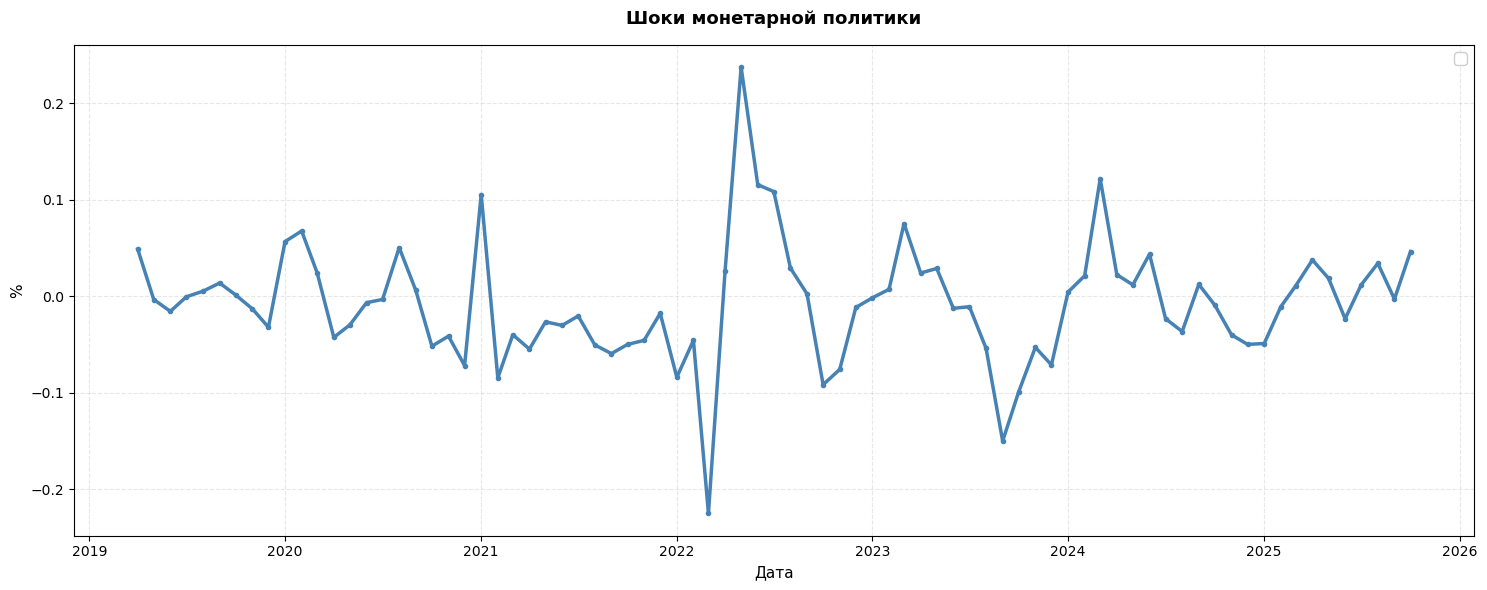


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ
           Mon_Shock
Среднее    -0.007308
Медиана    -0.009178
Ст. откл.   0.061867
Мин.       -0.224779
Макс.       0.237499


In [56]:
###############################
# ВЫДЕЛЕНИЕ ШОКОВ МОНЕТАРНОЙ ПОЛИТИКИ
###############################
df_taylor['Taylor_Predicted'] = model9.fittedvalues
df_taylor['Mon_Shock'] = df_taylor['D_log_Nominal_Percent_Rate'] - df_taylor['Taylor_Predicted']

print("\n" + "="*60)
print("Визуализация шоков монетарной политики")
print("="*60)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(df_taylor['Date'], df_taylor['Mon_Shock'], 
         linewidth=2.5, color='steelblue', linestyle='-', marker='o', markersize=3)
ax1.set_title('Шоки монетарной политики', 
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=11, framealpha=0.95)
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_ylabel('%', fontsize=11)
ax1.set_xlabel('Дата', fontsize=11)
ax1.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ
###############################
shock_series = df_taylor['Mon_Shock'].dropna()

desc_stats = {
    'Среднее': shock_series.mean(),
    'Медиана': shock_series.median(),
    'Ст. откл.': shock_series.std(),
    'Мин.': shock_series.min(),
    'Макс.': shock_series.max()
}

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ШОКИ МОНЕТАРНОЙ ПОЛИТИКИ")
print("="*60)

desc_df = pd.DataFrame(desc_stats, index=['Mon_Shock']).T
print(desc_df.round(6).to_string())

In [57]:
###############################
    #Тест на стационарность для шоков монетарной политики
###############################
variables_to_test = ['Mon_Shock']

df_test = df_taylor[variables_to_test]

stationarity_results = []
for var in variables_to_test:
    result = stationarity_tests(df_taylor[var], var)
    stationarity_results.append(result)

stationarity_df = pd.DataFrame(stationarity_results)
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ")
print("="*60)
print(stationarity_df.to_string())


РЕЗУЛЬТАТЫ ТЕСТОВ ДЛЯ ШОКОВ
    Variable  ADF_Statistic   ADF_p_value  ADF_Critical_1%  ADF_Critical_5%  ADF_Critical_10%  ADF_Stationary  KPSS_Statistic  KPSS_p_value  KPSS_Critical_1%  KPSS_Critical_5%  KPSS_Critical_10%  KPSS_Stationary  DF_GLS_Statistic  DF_GLS_p_value  DF_GLS_Critical_1%  DF_GLS_Critical_5%  DF_GLS_Critical_10%  DF_GLS_Stationary
0  Mon_Shock      -5.689983  8.113084e-07        -3.517114        -2.899375         -2.586955            True        0.053837           0.1             0.739             0.463              0.347             True          -4.72405        0.000004            -2.80509           -2.184101            -1.873412               True


In [58]:
##############################
# Тест Фридмана на сезонность
##############################
variables_for_analysis = [
    ('Mon_Shock', 'Шоки монетарной политики')]
friedman_results = []

for var_col, var_name in variables_for_analysis:
    if var_col in df_taylor.columns:
        result = friedman_seasonality_test(df_taylor, date_col='Date', 
                                          value_col=var_col, 
                                          test_name=var_name)
        if result:
            friedman_results.append(result)

# Сохраняем результаты Фридмана
friedman_summary = pd.DataFrame([
    {
        'Variable': r['variable'],
        'Chi_Squared': r['chi_squared'],
        'P_Value': r['p_value'],
        'Has_Seasonality': r['has_seasonality'],
        'N_Years': r['n_years'],
        'N_Months': r['n_months']
    } 
    for r in friedman_results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА")
print("="*80)
print(friedman_summary.to_string(index=False))


РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                Variable  Chi_Squared  P_Value  Has_Seasonality  N_Years  N_Months
Шоки монетарной политики    14.753846 0.194046            False        5        12



ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ


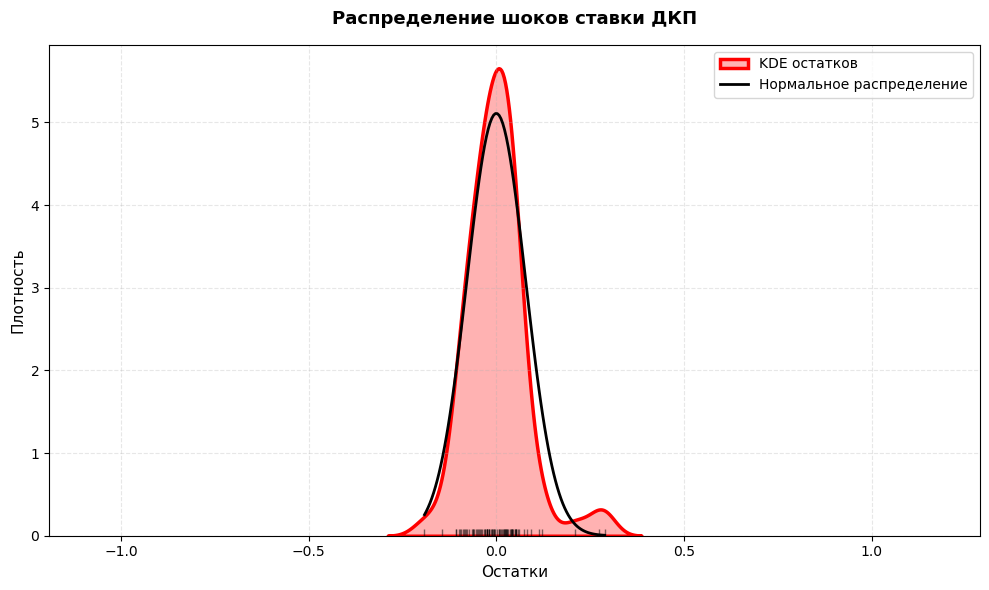


Параметры распределения:
  Среднее остатков: 0.000000
  Стд. отклонение: 0.078086
  Асимметрия (Skewness): 1.0940
  Эксцесс (Kurtosis): 3.2527
  N наблюдений: 79


In [59]:
###############################
# Ядерная оценка плотности распределения остатков
###############################
from scipy import stats
# Получаем остатки из лучшей модели
residuals = model9.resid

print("\n" + "="*80)
print("ЯДЕРНАЯ ОЦЕНКА ПЛОТНОСТИ РАСПРЕДЕЛЕНИЯ ОСТАТКОВ МОДЕЛИ")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 6))

# KDE + гистограмма
sns.kdeplot(residuals, fill=True, color='red', alpha=0.3, linewidth=2.5, label='KDE остатков')

# Нормальное распределение для сравнения
mu = residuals.mean()
sigma = residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
normal_dist = stats.norm.pdf(x, mu, sigma)
ax.plot(x, normal_dist, 'k-', linewidth=2, label='Нормальное распределение')

# Галочки остатков внизу оси X
for residual in residuals:
    ax.plot(residual, 0, '|', color='black', markersize=10, alpha=0.5)

ax.set_title('Распределение шоков ставки ДКП', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Остатки', fontsize=11)
ax.set_ylabel('Плотность', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim(residuals.min() - 1, residuals.max() + 1)

plt.tight_layout()
plt.show()

print(f"\nПараметры распределения:")
print(f"  Среднее остатков: {residuals.mean():.6f}")
print(f"  Стд. отклонение: {residuals.std():.6f}")
print(f"  Асимметрия (Skewness): {stats.skew(residuals):.4f}")
print(f"  Эксцесс (Kurtosis): {stats.kurtosis(residuals):.4f}")
print(f"  N наблюдений: {len(residuals)}")


In [60]:
mon_shock_dataset = df_taylor[['Date', 'Mon_Shock']].copy()
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(mon_shock_dataset, f)